In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ── 1. LOAD ──────────────────────────────────────────────────────────────────
df = pd.read_parquet("data/aligned/caiso_lmp_era5_averaged.parquet")
df = df.sort_values("time").reset_index(drop=True)

ZONES = ["NP15", "SP15", "ZP26"]
HORIZONS = [1, 2, 3, 4, 5, 6]  # hours ahead
USE_NET_LOAD = True

In [3]:
# ── 2. UNIT CONVERSION ───────────────────────────────────────────────────────
# ERA5 ssrd/fdir are accumulated J/m² per hour → convert to mean W/m²
for z in ZONES:
    df[f"ssrd_{z}"] = df[f"ssrd_{z}"] / 3600.0
    df[f"fdir_{z}"] = df[f"fdir_{z}"] / 3600.0

In [4]:
# ── 3. TARGET: total CAISO net load  ─────────────────────────
# Convert all load columns from MW --> GW
for load_col in ["Load_SP15", "Solar_SP15", "Wind_SP15"]:
    df[load_col] /= 1000.0

# The load is actually reported for the entire region, so just pick any hub and use its values.
df["total_load"] = df["Load_SP15"]
df["net_load"] = df["Load_SP15"] - (df["Solar_SP15"] + df["Wind_SP15"])

# Per-horizon targets: actual future load minus current load (signed ramp)
# We predict the MAGNITUDE, but keep signed version for inspection
for h in HORIZONS:
    df[f"load_ramp_{h}h"] = df["total_load"].shift(-h) - df["total_load"]
    df[f"net_load_ramp_{h}h"] = df["net_load"].shift(-h) - df["net_load"]
    df[f"net_load_ramp_magnitude_{h}h"] = df[f"net_load_ramp_{h}h"].abs()
    df[f"ramp_magnitude_{h}h"] = df[f"load_ramp_{h}h"].abs()


In [5]:
# ── 4. FEATURE ENGINEERING ───────────────────────────────────────────────────
for z in ZONES:
    # --- Solar features ---
    df[f"solar_ramp_1h_{z}"]  = df[f"ssrd_{z}"] - df[f"ssrd_{z}"].shift(1)
    df[f"solar_ramp_3h_{z}"]  = df[f"ssrd_{z}"] - df[f"ssrd_{z}"].shift(3)
    df[f"fdir_ratio_{z}"]     = df[f"fdir_{z}"] / (df[f"ssrd_{z}"] + 1e-3)

    # --- Temperature features ---
    df[f"temp_ramp_3h_{z}"]   = df[f"t2m_{z}"] - df[f"t2m_{z}"].shift(3)
    df[f"temp_roll_max_6h_{z}"] = df[f"t2m_{z}"].rolling(6).max()
    df[f"temp_roll_max_24h_{z}"] = df[f"t2m_{z}"].rolling(24).max()

    # --- Cloud cover features ---
    df[f"tcc_delta_1h_{z}"]   = df[f"tcc_{z}"] - df[f"tcc_{z}"].shift(1)
    df[f"tcc_delta_3h_{z}"]   = df[f"tcc_{z}"] - df[f"tcc_{z}"].shift(3)

    # --- Wind features ---
    df[f"wind_ramp_1h_{z}"]   = df[f"wind_speed_{z}"] - df[f"wind_speed_{z}"].shift(1)

# --- Load autoregressive features. Load is the same across all zones ---
df["total_load_lag_1h"]     = df["total_load"].shift(1)
df["total_load_lag_2h"]     = df["total_load"].shift(2)
df["total_load_lag_3h"]     = df["total_load"].shift(3)
df["total_load_ramp_lag_1h"] = df["total_load"].shift(1) - df["total_load"].shift(2)
df["total_load_ramp_lag_2h"] = df["total_load"].shift(2) - df["total_load"].shift(3)

df["net_load_lag_1h"]     = df["net_load"].shift(1)
df["net_load_lag_2h"]     = df["net_load"].shift(2)
df["net_load_lag_3h"]     = df["net_load"].shift(3)
df["net_load_ramp_lag_1h"] = df["net_load"].shift(1) - df["net_load"].shift(2)
df["net_load_ramp_lag_2h"] = df["net_load"].shift(2) - df["net_load"].shift(3)

# --- Cyclical calendar encodings (replaces raw hour/month integers) ---
# Assuming df["time"] is already datetime in UTC (no tz info or tz='UTC')
# First, localize to UTC then convert to Pacific
df["time_pst"] = pd.to_datetime(df["time"]).dt.tz_convert("US/Pacific")

# Extract components in local time
hour_of_day = df["time_pst"].dt.hour
doy = df["time_pst"].dt.dayofyear
day_of_week = df["time_pst"].dt.dayofweek  # 0=Monday, 6=Sunday

# Now compute encodings
df["hour_sin"] = np.sin(2 * np.pi * hour_of_day / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour_of_day / 24)
df["doy_sin"]  = np.sin(2 * np.pi * doy / 365)
df["doy_cos"]  = np.cos(2 * np.pi * doy / 365)
df["dow_sin"]  = np.sin(2 * np.pi * day_of_week / 7)
df["dow_cos"]  = np.cos(2 * np.pi * day_of_week / 7)

# Optional: drop the intermediate column
# df = df.drop("time_pst", axis=1)

In [8]:
df.columns

Index(['time', 'Congestion_NP15', 'Congestion_SP15', 'Congestion_ZP26',
       'Energy_NP15', 'Energy_SP15', 'Energy_ZP26', 'Lmp_NP15', 'Lmp_SP15',
       'Lmp_ZP26',
       ...
       'net_load_lag_3h', 'net_load_ramp_lag_1h', 'net_load_ramp_lag_2h',
       'time_pst', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'dow_sin',
       'dow_cos'],
      dtype='object', length=135)

In [6]:
# ── 5. FEATURE COLUMNS ───────────────────────────────────────────────────────
# Raw weather (per zone)
raw_wx = [f"{v}_{z}" for z in ZONES
          for v in ["t2m", "tcc", "tcwv", "ssrd", "fdir", "wind_speed", "rh", "tp"]]


# Engineered features (per zone)
eng_wx = [c for c in df.columns if any(c.startswith(p) for p in [
    "solar_ramp", "fdir_ratio", "temp_ramp", "temp_roll_max",
    "tcc_delta", "wind_ramp", #"load_lag", "load_ramp_lag"
]) and not c.startswith("load_ramp_") and not c.startswith("ramp_magnitude")  
          and not c.startswith("net_load_ramp_")   # ← add this guard
          and not c.startswith("net_load_ramp_magnitude")]
         #and not "lag" in c]

# System-level AR + calendar
system_feats = [
    "total_load_lag_1h", "total_load_lag_2h", "total_load_lag_3h",
    "total_load_ramp_lag_1h", "total_load_ramp_lag_2h",
    "hour_sin", "hour_cos", "doy_sin", "doy_cos",
    "dow_sin", "dow_cos", "is_weekend",
]
if USE_NET_LOAD:
    system_feats += [
        "net_load_lag_1h", "net_load_lag_2h", "net_load_lag_3h",
        "net_load_ramp_lag_1h", "net_load_ramp_lag_2h", 
         "Solar_SP15", "Wind_SP15"]
FEATURE_COLS = raw_wx + eng_wx + system_feats
print(f"Total features: {len(FEATURE_COLS)}")

# Refit HGB with FEATURE_COLS_NO_TIME and compare MAE
# Expect ~5-15% degradation at 1h, less at 3h


Total features: 70


In [7]:
# Drop redundant zone load columns and their derived features
load_dupe_cols = [c for c in FEATURE_COLS if any(
    c.startswith(pfx) for pfx in ["load_lag_1h_", "load_ramp_lag_1h_"]
)]
# Replace with just the system-level AR features you already have:
# total_load_lag_1h, total_load_lag_2h, total_load_lag_3h,
# total_load_ramp_lag_1h, total_load_ramp_lag_2h
FEATURE_COLS_CLEAN = [c for c in FEATURE_COLS if c not in load_dupe_cols]
print(f"Reduced from {len(FEATURE_COLS)} → {len(FEATURE_COLS_CLEAN)} features")
# Should drop ~6 features (3 zones × 2 lag types)

Reduced from 70 → 70 features


In [91]:
'load_lag_1h' in FEATURE_COLS

False

In [8]:
TIME_COLS = ["hour_sin", "hour_cos", "doy_sin", "doy_cos", "dow_sin", "dow_cos", "is_weekend"]
FEATURE_COLS_NO_TIME = [c for c in FEATURE_COLS_CLEAN if c not in TIME_COLS]
FEATURE_COLS = FEATURE_COLS_NO_TIME

In [9]:
# ── 6. TRAIN / VAL / TEST SPLIT (time-based) ─────────────────────────────────
# Use the Pacific time to choose train/test split
time_col = pd.to_datetime(df["time_pst"])

# With h_max=6 and max lookback = 24h rolling window:
GAP_HOURS = 6 + 24  # = 30 hours minimum

# Concretely:
train_end   = pd.Timestamp("2024-12-31 00:00:00", tz="US/Pacific")
gap_end     = pd.Timestamp("2025-01-01 06:00:00", tz="US/Pacific")  # 30h gap
test_start  = gap_end

train_mask = time_col <= train_end
gap_mask   = (time_col > train_end) & (time_col < test_start)
test_mask  = time_col >= test_start

# Exclude gap rows from both train and test entirely

print(f"Train rows: {train_mask.sum()}, Test: {test_mask.sum()}")


Train rows: 15001, Test: 7218


In [15]:
HORIZONS

[1, 2, 3, 4, 5, 6]

In [42]:
from sklearn.inspection import permutation_importance

# ── 7. MODEL + EVAL LOOP ─────────────────────────────────────────────────────
results = []

for h in HORIZONS:
    if USE_NET_LOAD:
        target = f"net_load_ramp_magnitude_{h}h"
        # Include the "net_load" column for the persistence baseline.
        valid = df[FEATURE_COLS + [target, "net_load"]].dropna()

    else:
        target = f"ramp_magnitude_{h}h"
        valid = df[FEATURE_COLS + [target, "total_load"]].dropna()

    # Drop NaNs from lags and from shift(-h) at end of series
    valid_idx = valid.index

    # Re-apply time masks on valid subset
    tr = valid[train_mask.loc[valid.index]] #valid[time_col[valid_idx].dt.year.isin([2023, 2024])]
    te = valid[test_mask.loc[valid.index]] #valid[time_col[valid_idx].dt.year == 2025]

    X_tr, y_tr = tr[FEATURE_COLS], tr[target]
    X_te, y_te = te[FEATURE_COLS], te[target] 
    # --- Persistence baseline: ramp magnitude = |load_t - load_{t-1}| ---
    if USE_NET_LOAD:
        persist_te  = te["net_load"].diff().abs().fillna(0)
    else:
        persist_te  = te["total_load"].diff().abs().fillna(0)

    # --- Linear Regression ---
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    lr = LinearRegression()
    lr.fit(X_tr_s, y_tr)

    # --- HGB Regressor ---
    # Apply log scaling
    hgb = HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.05,
        max_depth=6,
        min_samples_leaf=20,
        random_state=42,
    )
    hgb.fit(X_tr, y_tr)
    feat_imp = permutation_importance(hgb, X_te, y_te, n_repeats=10, random_state=42)
    imp_df = pd.DataFrame({
        "feature": FEATURE_COLS,
        "importance": feat_imp.importances_mean
    })
    
    top10 = imp_df.sort_values("importance", ascending=False).head(10)
    
    print(f"Horizon {h}:")
    print(top10["feature"].tolist())
    
    for split_name, X_lr, X_hgb, y_true, persist_pred in [
        ("test", X_te_s, X_te, y_te, persist_te),
    ]:
        for model_name, preds in [
            ("persistence", persist_pred.values[:len(y_true)]),
            ("linear_reg",  lr.predict(X_lr)),
            ("hgb",         hgb.predict(X_hgb)),
        ]:
            mae  = mean_absolute_error(y_true, preds)
            rmse = root_mean_squared_error(y_true, preds)
            # Normalize MAE by mean ramp magnitude in the test set
            mean_ramp = y_te.mean()
            results.append({
                "horizon": f"{h}h",
                "split": split_name,
                "model": model_name,
                "MAE_MW": round(mae, 4),
                "RMSE_MW": round(rmse, 4),
                "mean_ramp": mean_ramp,
                "mae_%": mae/mean_ramp,
            })

Horizon 1:
['Solar_SP15', 'total_load_ramp_lag_1h', 'ssrd_SP15', 'solar_ramp_3h_NP15', 'solar_ramp_1h_SP15', 'net_load_ramp_lag_1h', 'solar_ramp_3h_SP15', 'net_load_ramp_lag_2h', 'temp_ramp_3h_SP15', 'ssrd_ZP26']
Horizon 2:
['Solar_SP15', 'net_load_ramp_lag_1h', 'solar_ramp_1h_SP15', 'solar_ramp_3h_SP15', 'total_load_ramp_lag_1h', 'ssrd_SP15', 'temp_ramp_3h_SP15', 'net_load_ramp_lag_2h', 'solar_ramp_3h_NP15', 'temp_roll_max_24h_SP15']
Horizon 3:
['solar_ramp_1h_SP15', 'Solar_SP15', 'net_load_ramp_lag_1h', 'total_load_ramp_lag_1h', 'solar_ramp_3h_SP15', 'temp_roll_max_24h_SP15', 'net_load_lag_1h', 'ssrd_SP15', 'solar_ramp_3h_NP15', 'net_load_lag_3h']
Horizon 4:
['net_load_ramp_lag_1h', 'solar_ramp_3h_NP15', 'solar_ramp_1h_SP15', 'Solar_SP15', 'net_load_lag_3h', 'ssrd_SP15', 'temp_roll_max_24h_SP15', 'solar_ramp_3h_SP15', 'total_load_ramp_lag_1h', 'net_load_lag_1h']
Horizon 5:
['net_load_ramp_lag_1h', 'solar_ramp_3h_NP15', 'ssrd_SP15', 'solar_ramp_1h_SP15', 'temp_roll_max_24h_SP15', 'Sol

In [43]:
top_features = {
1: ['Solar_SP15', 'total_load_ramp_lag_1h', 'ssrd_SP15', 'solar_ramp_3h_NP15', 'solar_ramp_1h_SP15', 'net_load_ramp_lag_1h', 'solar_ramp_3h_SP15', 'net_load_ramp_lag_2h', 'temp_ramp_3h_SP15', 'ssrd_ZP26'],
2: ['Solar_SP15', 'net_load_ramp_lag_1h', 'solar_ramp_1h_SP15', 'solar_ramp_3h_SP15', 'total_load_ramp_lag_1h', 'ssrd_SP15', 'temp_ramp_3h_SP15', 'net_load_ramp_lag_2h', 'solar_ramp_3h_NP15', 'temp_roll_max_24h_SP15'],
3: ['solar_ramp_1h_SP15', 'Solar_SP15', 'net_load_ramp_lag_1h', 'total_load_ramp_lag_1h', 'solar_ramp_3h_SP15', 'temp_roll_max_24h_SP15', 'net_load_lag_1h', 'ssrd_SP15', 'solar_ramp_3h_NP15', 'net_load_lag_3h'],
4: ['net_load_ramp_lag_1h', 'solar_ramp_3h_NP15', 'solar_ramp_1h_SP15', 'Solar_SP15', 'net_load_lag_3h', 'ssrd_SP15', 'temp_roll_max_24h_SP15', 'solar_ramp_3h_SP15', 'total_load_ramp_lag_1h', 'net_load_lag_1h'],
5: ['net_load_ramp_lag_1h', 'solar_ramp_3h_NP15', 'ssrd_SP15', 'solar_ramp_1h_SP15', 'temp_roll_max_24h_SP15', 'Solar_SP15', 'net_load_lag_1h', 'net_load_lag_3h', 'total_load_ramp_lag_1h', 'solar_ramp_3h_SP15'],
6: ['ssrd_SP15', 'solar_ramp_1h_SP15', 'temp_roll_max_24h_SP15', 'total_load_lag_2h', 'net_load_lag_1h', 'Solar_SP15', 'net_load_ramp_lag_1h', 'solar_ramp_3h_NP15', 'solar_ramp_3h_SP15', 'fdir_ratio_SP15']
}

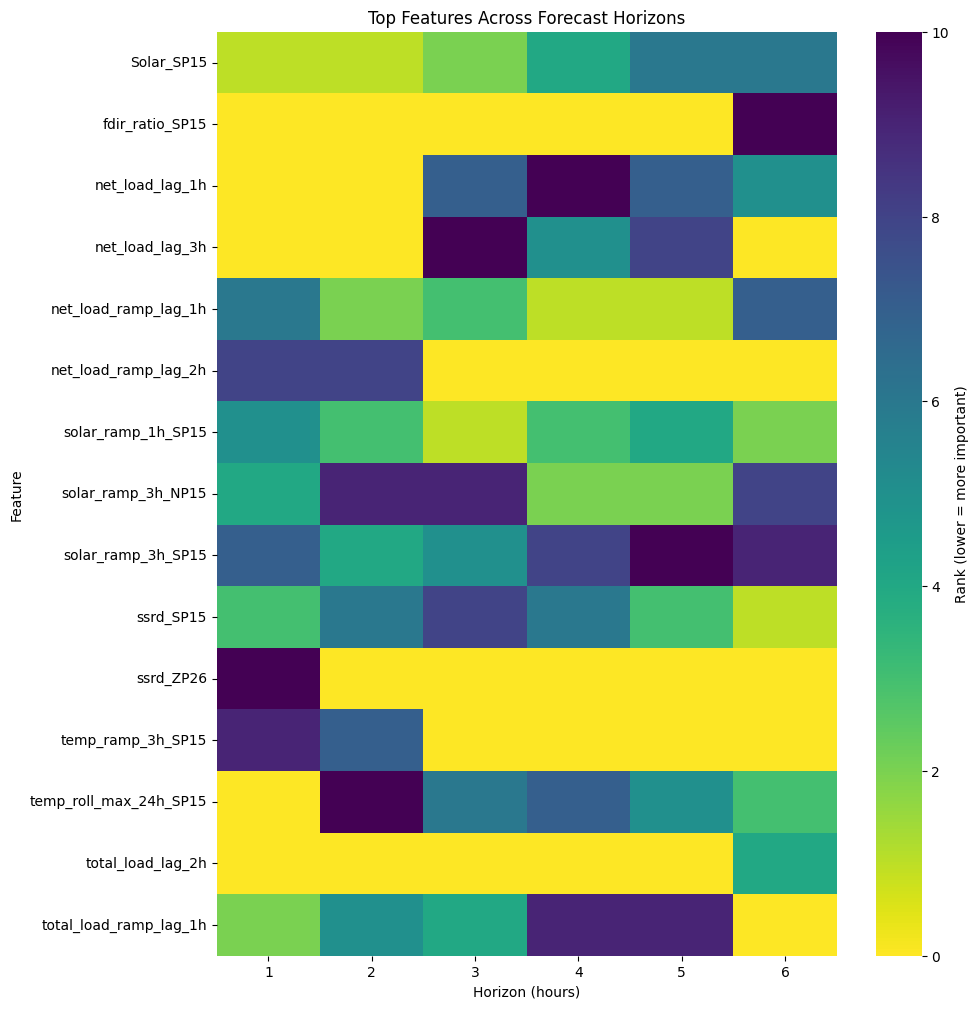

In [55]:
import seaborn as sns
# Get all unique features
all_feats = sorted(set(f for lst in top_features.values() for f in lst))

# Build matrix (use rank: 1 = most important)
mat = pd.DataFrame(index=all_feats, columns=top_features.keys())

for h, feats in top_features.items():
    for rank, f in enumerate(feats, start=1):
        mat.loc[f, h] = rank

# Optional: fill NaN with 0 for "not present"
mat = mat.fillna(0)

plt.figure(figsize=(10, 12))
sns.heatmap(mat, cmap="viridis_r", cbar_kws={"label": "Rank (lower = more important)"})
plt.xlabel("Horizon (hours)")
plt.ylabel("Feature")
plt.title("Top Features Across Forecast Horizons")

plt.savefig('writeup_figures/hgb_feature_importance_matrix.png')
plt.show()


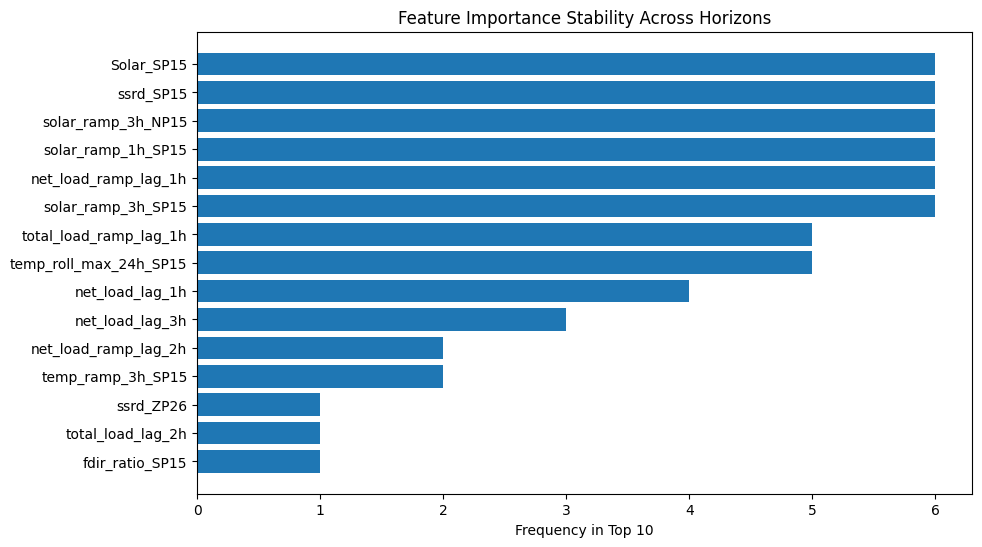

In [58]:
from collections import Counter
import matplotlib.pyplot as plt

counts = Counter(f for lst in top_features.values() for f in lst)

feat, freq = zip(*counts.most_common())

plt.figure(figsize=(10, 6))
plt.barh(feat[::-1], freq[::-1])
plt.xlabel("Frequency in Top 10")
plt.title("Feature Importance Stability Across Horizons")

plt.savefig('writeup_figures/hgb_feature_importance_bar_chart.png', bbox_inches='tight')
plt.show()


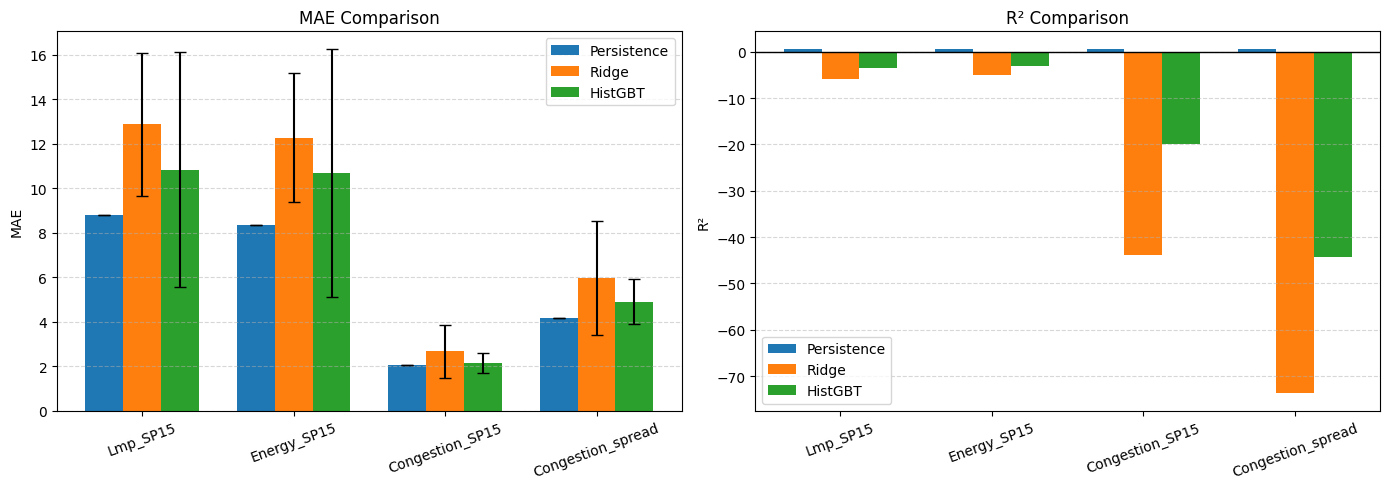

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Data
# -----------------------------
experiments = [
    "Lmp_SP15",
    "Energy_SP15",
    "Congestion_SP15",
    "Congestion_spread"
]

models = ["Persistence", "Ridge", "HistGBT"]

# MAE values
mae = np.array([
    [8.790, 12.869, 10.841],
    [8.337, 12.280, 10.670],
    [2.050, 2.672, 2.122],
    [4.157, 5.959, 4.901],
])

# MAE std (0 for persistence since not provided)
mae_std = np.array([
    [0.0, 3.232, 5.301],
    [0.0, 2.912, 5.573],
    [0.0, 1.196, 0.450],
    [0.0, 2.555, 1.013],
])

# R^2 values
r2 = np.array([
    [0.704, -5.945, -3.448],
    [0.697, -4.999, -3.028],
    [0.541, -43.835, -19.879],
    [0.532, -73.746, -44.225],
])

# -----------------------------
# Plot settings
# -----------------------------
x = np.arange(len(experiments))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# -----------------------------
# MAE Plot
# -----------------------------
ax = axes[0]
for i, model in enumerate(models):
    ax.bar(
        x + (i - 1) * width,
        mae[:, i],
        width,
        yerr=mae_std[:, i],
        capsize=4,
        label=model
    )

ax.set_title("MAE Comparison")
ax.set_ylabel("MAE")
ax.set_xticks(x)
ax.set_xticklabels(experiments, rotation=20)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# -----------------------------
# R² Plot
# -----------------------------
ax = axes[1]
for i, model in enumerate(models):
    ax.bar(
        x + (i - 1) * width,
        r2[:, i],
        width,
        label=model
    )

ax.set_title("R² Comparison")
ax.set_ylabel("R²")
ax.set_xticks(x)
ax.set_xticklabels(experiments, rotation=20)
ax.axhline(0, color='black', linewidth=1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# -----------------------------
# Layout
# -----------------------------
fig.tight_layout()
fig.savefig('writeup_figures/bar_plots.png', dpi=300, bbox_inches='tight')
#plt.savefig('writeup_figures/bar_plots.png')
plt.show()

In [11]:
results_df = pd.DataFrame(results)
print("Net Load Ramp", results_df.to_string(index=False))

Net Load Ramp horizon split       model  MAE_MW  RMSE_MW  mean_ramp    mae_%
     1h  test persistence  1.4910   2.3689   2.195090 0.679263
     1h  test  linear_reg  1.1530   1.6206   2.195090 0.525260
     1h  test         hgb  0.5119   0.7493   2.195090 0.233204
     2h  test persistence  3.1060   4.7552   4.231070 0.734082
     2h  test  linear_reg  2.1711   2.9083   4.231070 0.513144
     2h  test         hgb  0.9801   1.4916   4.231070 0.231635
     3h  test persistence  4.8562   7.0354   6.086104 0.797917
     3h  test  linear_reg  2.8863   3.7354   6.086104 0.474252
     3h  test         hgb  1.3680   2.0496   6.086104 0.224770
     4h  test persistence  6.4999   8.9452   7.756293 0.838015
     4h  test  linear_reg  3.4310   4.3367   7.756293 0.442348
     4h  test         hgb  1.6501   2.4298   7.756293 0.212746
     5h  test persistence  7.9962  10.5390   9.246012 0.864832
     5h  test  linear_reg  3.8271   4.7383   9.246012 0.413924
     5h  test         hgb  1.9398   2.785

In [25]:
hgb_mae = results_df.loc[results_df["model"] == "hgb"]["MAE_MW"].values
lr_mae = results_df.loc[results_df["model"] == "linear_reg"]["MAE_MW"].values
persistence_mae = results_df.loc[results_df["model"] == "persistence"]["MAE_MW"].values
transformer_mae = np.array([0.4550, 0.7576, 0.9663, 1.1458, 1.2982, 1.4581])


In [35]:
transformer_mae

array([0.455 , 0.7576, 0.9663, 1.1458, 1.2982, 1.4581])

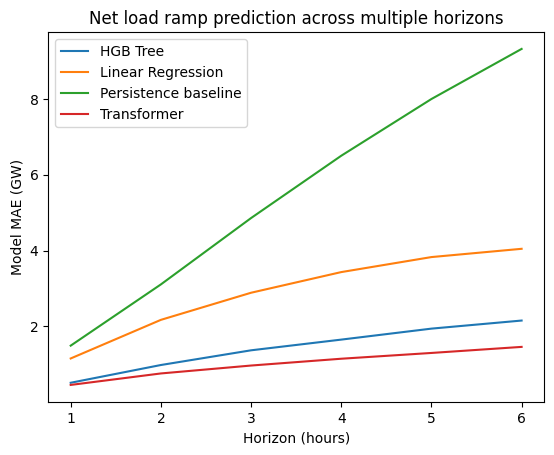

In [56]:
from matplotlib import pyplot as plt
x = np.arange(1, 7)
plt.plot(x, hgb_mae, label='HGB Tree')
plt.plot(x, lr_mae, label='Linear Regression')
plt.plot(x, persistence_mae, label='Persistence baseline')
plt.plot(x, transformer_mae, label='Transformer')

plt.xlabel('Horizon (hours)')
plt.ylabel('Model MAE (GW)')
plt.title('Net load ramp prediction across multiple horizons')
plt.legend()

plt.savefig('writeup_figures/ramp_horizon_comparison.png')
plt.show()


In [36]:
#df_clean = df.dropna()
#X = df_clean[FEATURE_COLS].values.astype(np.float32)      # [T, 63]
#y = df_clean["ramp_magnitude_1h"].values.astype(np.float32)  # scalar ramp at t+1

In [19]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd

# Assume you already:
# - have a DataFrame `df` with columns: FEATURE_COLS + ramp targets
# - fixed `FEATURE_COLS` as above (63 features)

L = 168  # lookback: 1 week in hours
H = 6    # prediction horizon: 1–6h ahead

df_clean = df.dropna()

X = df_clean[FEATURE_COLS].values.astype(np.float32)      # [T, 63]
if USE_NET_LOAD:
    TARGET_COLS = TARGET_COLS = [f"net_load_ramp_magnitude_{h}h" for h in range(1, H+1)]  # H=6
else:
    TARGET_COLS = [f"ramp_magnitude_{h}h" for h in range(1, H+1)]  # H=6
y = df_clean[TARGET_COLS].values.astype(np.float32)  # [T, 6]
# y is ramp_magnitude (MW) -> log‑scale
y_log = y  # shape [T, 6] if you use multi‑output
print("Y_LOG shape", y_log.shape)

class RampDataset(Dataset):
    def __init__(self, X, y, L, H, t_dim_as_feature=False):
        """
        X: [T, F]
        y: [T] ramp at t+1 (you can extend to vector y = [ramp_1h, ..., ramp_6h])
        """
        self.X = X
        self.y = y
        self.L = L
        self.H = H
        self.t_dim_as_feature = t_dim_as_feature
        self.valid_indices = range(L, len(X) - H + 1)

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        # Map idx ∈ [0, len(valid_indices)-1] to true time index
        t = self.valid_indices[idx]
        x_hist = self.X[t - L : t]  # [L, F]
        if self.t_dim_as_feature:
            x_hist = x_hist.transpose(1, 0)
        y_fwd  = self.y[t]  # [H] magnitudes at t+1, ..., t+H extracted from the ramp_magnitude_H columns
        return torch.from_numpy(x_hist), torch.from_numpy(y_fwd)

# Filter train/test times FIRST, then create datasets
time_col = pd.to_datetime(df_clean["time"])
train_mask = time_col <= pd.Timestamp("2024-12-31", tz="UTC")
test_mask  = time_col >= pd.Timestamp("2025-01-07", tz="UTC")  # 30h gap enforced

X_train, y_train = X[train_mask], y_log[train_mask]
X_test,  y_test  = X[test_mask],  y_log[test_mask]

# Normalize only the physical columns (not the time cols)
TIME_COLS = ["hour_sin", "hour_cos", "doy_sin", "doy_cos", "dow_sin", "dow_cos", "is_weekend"]

time_col_idx = [FEATURE_COLS.index(c) for c in TIME_COLS]
phys_col_idx = [i for i in range(len(FEATURE_COLS)) if i not in time_col_idx]
X_train_phys = X_train[:, phys_col_idx]
X_test_phys = X_test[:, phys_col_idx]

scaler = StandardScaler()
X_train_phys = scaler.fit_transform(X_train_phys)
X_test_phys = scaler.transform(X_test_phys)
# Recombine with the time columns after scaling.
X_train = np.hstack([X_train_phys, X_train[:, time_col_idx]])
X_test = np.hstack([X_test_phys, X_test[:, time_col_idx]])

# Now construct the dataset
ds_train = RampDataset(X_train, y_train, L, H, t_dim_as_feature=False)
ds_test  = RampDataset(X_test,  y_test,  L, H, t_dim_as_feature=False)

dl_train = DataLoader(ds_train, batch_size=8, shuffle=True,  num_workers=0)
dl_test  = DataLoader(ds_test,  batch_size=8, shuffle=False, num_workers=0)

Y_LOG shape (22138, 6)


In [21]:
x,y = next(iter(dl_train))
x.shape, y.shape

(torch.Size([8, 168, 70]), torch.Size([8, 6]))

In [113]:
np.isnan(X).any(), np.isnan(y_log).any(), np.isinf(X).any(), np.isinf(y_log).any()

(np.False_, np.False_, np.False_, np.False_)

In [20]:
class CustomEncoderLayer(nn.TransformerEncoderLayer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
    
    def forward(self, src, src_mask=None, src_key_padding_mask=None):
        x = src

        attn_output, attn_weights = self.self_attn(
            x, x, x,
            attn_mask=src_mask,
            key_padding_mask=src_key_padding_mask,
            need_weights=True,
            average_attn_weights=False  # keep per-head weights
        )

        x = x + self.dropout1(attn_output)
        x = self.norm1(x)

        x2 = self.linear2(self.dropout(self.activation(self.linear1(x))))
        x = x + self.dropout2(x2)
        x = self.norm2(x)

        return x, attn_weights

In [22]:
import torch.nn.functional as F

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: [B, L, d_model]
        B, L, d_model = x.shape
        # Grab the first L positions; pe is [1, max_len, d_model]
        pe = self.pe[:, :L]  # [1, L, d_model]
        x = x + pe  # [B, L, d_model] + [L, 1, d_model] → OK
        return self.dropout(x)


class TemporalRampTransformer(nn.Module):
    def __init__(self, C, L, H, d_model=128, nhead=8, nlayers=4, dropout=0.1):
        super().__init__()
        self.C = C
        self.L = L
        self.H = H
        self.d_model = d_model

        # Linear map: C features → d_model embedding
        self.proj = nn.Linear(C, d_model)

        # Pos encoding
        self.pos_enc = PositionalEncoding(d_model, dropout)

        # Transformer encoder (this is an all‑in‑one causal‑ish stack)
        # To get fully causal behavior, use custom src_mask; here we keep it simple
        # and let the model see the full history (like most time‑series transformers)
        """
        encoder_layer = nn.TransformerEncoderLayer(
            d_model,
            nhead,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            batch_first=True,
            #need_weights=True,
        )
        """
        encoder_layer = CustomEncoderLayer(
            d_model,
            nhead,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            batch_first=True,
        )
        
        self.encoder = nn.ModuleList([encoder_layer for _ in range(nlayers)])
        #self.encoder = nn.TransformerEncoder(encoder_layer, nlayers)

        # Head: aggregate over L and map to H outputs
        self.pooling = nn.Linear(d_model, d_model)
        self.head = nn.Linear(d_model, H)  # one output per horizon (1–6h)

    def forward(self, x):
        # x: [B, L, C]
        B, L, C = x.shape
        assert L == self.L, f"x has L={L}, expected {self.L}"

        # Embed: [B, L, C] → [B, L, d_model]
        x = self.proj(x)

        # Pos enc
        x = self.pos_enc(x)

        # Transformer encoder over L steps
        #x = self.encoder(x)  # [B, L, d_model]
        attn_maps = []

        for layer in self.encoder:
            x, attn = layer(x)
            attn_maps.append(attn)

        # Pool over time (you could use just the last token or mean)
        x = x.mean(dim=1)    # [B, d_model]
        x = F.relu(self.pooling(x))

        # Heads: [B, d_model] → [B, H]
        y_pred = self.head(x)  # [B, H]
        return y_pred, attn_maps

In [23]:
import torch.optim as optim
import os
from datetime import datetime

CKPT_DIR = "net_load_ramp_model_4h_256proj/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

best_val_rmse = float("inf")
best_epoch = -1

model = TemporalRampTransformer(
    C=len(FEATURE_COLS),
    L=L,
    H=H,
    d_model=256, #128,
    nhead=4, #8,
    nlayers=4,
    dropout=0.1,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.MSELoss()  # or use MAE: L1 loss

# Optional: scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)

from tqdm.auto import tqdm

EPOCHS = 50
LOG_FREQ = 10  # log every 10 batches

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    n_batches = 0

    # Wrap the dataloader with tqdm
    pbar = tqdm(dl_train, desc=f"Epoch {epoch}")

    for i, (x, y) in enumerate(pbar):
        x, y = x.to(device), y.to(device)
        y_pred, _ = model(x)  # [B, H]
        loss = criterion(y_pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()

        # Accumulate loss
        train_loss += loss.item()
        n_batches += 1

        # Log every LOG_FREQ batches
        if (i + 1) % LOG_FREQ == 0:
            avg_loss = train_loss / n_batches
            pbar.set_postfix({"loss": f"{avg_loss:.4f}"})

    # Log once per epoch (optional, but cleaner)
    print(f"Epoch {epoch} | Train avg loss: {train_loss/n_batches:.4f}")

    # Evaluation
    model.eval()
    val_loss = 0.0
    n_val_batches = 0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for x, y in dl_test:
            x, y = x.to(device), y.to(device)
            y_pred, _ = model(x)
            all_preds.append(y_pred)
            all_targets.append(y)
            loss = criterion(y_pred, y)
            val_loss += loss.item()
            n_val_batches += 1
    preds   = torch.cat(all_preds,   dim=0)  # [N, 6]
    targets = torch.cat(all_targets, dim=0)  # [N, 6]

    # Compute overall val RMSE (you could also use MAE or per‑horizon min)
    val_rmse = ((preds - targets)**2).mean().sqrt().item()
    # Per-horizon metrics matching your HGB table
    for i, h in enumerate(range(1, H+1)):
        error = preds[:, i] - targets[:, i]
        mae  = error.abs().mean().item()
        rmse = (error**2).mean().sqrt().item()
        mean_ramp = targets[:, i].mean().item()
        mae_pct = mae / mean_ramp
        print(f"{h}h | MAE: {mae:.4f} MW | RMSE: {rmse:.4f} MW | MAE_PCT: {mae_pct:5.3f}")        
    print(f"Epoch {epoch} | Val avg loss: {val_loss/n_val_batches:.4f}")

        # --- checkpoint if this is the best model so far ---
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_epoch = epoch

        # Save as best.pth
        ckpt_path = os.path.join(CKPT_DIR, "best_ramp_transformer.pth")
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_rmse": val_rmse,
            },
            ckpt_path,
        )
        print(f"  → Best model so far saved at {ckpt_path} (val RMSE: {val_rmse:.1f})")
    scheduler.step()

Epoch 0: 100%|███████████████████████████████████████████████████████████████| 1841/1841 [04:34<00:00,  6.70it/s, loss=10.2581]


Epoch 0 | Train avg loss: 10.2536
1h | MAE: 0.8568 MW | RMSE: 1.2656 MW | MAE_PCT: 0.389
2h | MAE: 1.4114 MW | RMSE: 2.0054 MW | MAE_PCT: 0.333
3h | MAE: 1.7602 MW | RMSE: 2.4236 MW | MAE_PCT: 0.288
4h | MAE: 2.0111 MW | RMSE: 2.6811 MW | MAE_PCT: 0.258
5h | MAE: 2.1879 MW | RMSE: 2.8558 MW | MAE_PCT: 0.236
6h | MAE: 2.4322 MW | RMSE: 3.1582 MW | MAE_PCT: 0.230
Epoch 0 | Val avg loss: 6.1393
  → Best model so far saved at net_load_ramp_model_4h_256proj/checkpoints/best_ramp_transformer.pth (val RMSE: 2.5)


Epoch 1: 100%|████████████████████████████████████████████████████████████████| 1841/1841 [04:38<00:00,  6.60it/s, loss=3.5127]


Epoch 1 | Train avg loss: 3.5114
1h | MAE: 0.6957 MW | RMSE: 1.0479 MW | MAE_PCT: 0.316
2h | MAE: 1.2220 MW | RMSE: 1.7937 MW | MAE_PCT: 0.288
3h | MAE: 1.4988 MW | RMSE: 2.1051 MW | MAE_PCT: 0.246
4h | MAE: 1.6444 MW | RMSE: 2.2455 MW | MAE_PCT: 0.211
5h | MAE: 1.7775 MW | RMSE: 2.3928 MW | MAE_PCT: 0.192
6h | MAE: 2.0017 MW | RMSE: 2.6704 MW | MAE_PCT: 0.189
Epoch 1 | Val avg loss: 4.4416
  → Best model so far saved at net_load_ramp_model_4h_256proj/checkpoints/best_ramp_transformer.pth (val RMSE: 2.1)


Epoch 2: 100%|████████████████████████████████████████████████████████████████| 1841/1841 [04:36<00:00,  6.67it/s, loss=2.6307]


...

Epoch 47 | Train avg loss: 0.3018
1h | MAE: 0.4516 MW | RMSE: 0.6651 MW | MAE_PCT: 0.205
2h | MAE: 0.7569 MW | RMSE: 1.1082 MW | MAE_PCT: 0.178
3h | MAE: 0.9904 MW | RMSE: 1.4231 MW | MAE_PCT: 0.162
4h | MAE: 1.1906 MW | RMSE: 1.6665 MW | MAE_PCT: 0.153
5h | MAE: 1.3781 MW | RMSE: 1.8909 MW | MAE_PCT: 0.149
6h | MAE: 1.5450 MW | RMSE: 2.1023 MW | MAE_PCT: 0.146
Epoch 47 | Val avg loss: 2.4147


Epoch 48: 100%|███████████████████████████████████████████████████████████████| 1841/1841 [04:06<00:00,  7.48it/s, loss=0.2894]


Epoch 48 | Train avg loss: 0.2893
1h | MAE: 0.4442 MW | RMSE: 0.6640 MW | MAE_PCT: 0.202
2h | MAE: 0.7385 MW | RMSE: 1.0902 MW | MAE_PCT: 0.174
3h | MAE: 0.9876 MW | RMSE: 1.4292 MW | MAE_PCT: 0.162
4h | MAE: 1.2030 MW | RMSE: 1.6944 MW | MAE_PCT: 0.155
5h | MAE: 1.3954 MW | RMSE: 1.9205 MW | MAE_PCT: 0.150
6h | MAE: 1.5601 MW | RMSE: 2.1246 MW | MAE_PCT: 0.147
Epoch 48 | Val avg loss: 2.4608


Epoch 49: 100%|███████████████████████████████████████████████████████████████| 1841/1841 [04:09<00:00,  7.38it/s, loss=0.2809]


Epoch 49 | Train avg loss: 0.2809
1h | MAE: 0.4712 MW | RMSE: 0.7003 MW | MAE_PCT: 0.214
2h | MAE: 0.7855 MW | RMSE: 1.1515 MW | MAE_PCT: 0.185
3h | MAE: 1.0242 MW | RMSE: 1.4600 MW | MAE_PCT: 0.168
4h | MAE: 1.2274 MW | RMSE: 1.7108 MW | MAE_PCT: 0.158
5h | MAE: 1.4202 MW | RMSE: 1.9349 MW | MAE_PCT: 0.153
6h | MAE: 1.5891 MW | RMSE: 2.1439 MW | MAE_PCT: 0.150
Epoch 49 | Val avg loss: 2.5375


In [24]:
# 4 heads, 256 dim
model.eval()
model.zero_grad()

x_sample, y_sample = next(iter(dl_test))
x_sample = x_sample.to(device).detach().requires_grad_(True)  # [B, L, F]

# Forward once; keep the graph alive across all backward calls
y_pred, _ = model(x_sample)  # [B, H]

for i in range(H):
    # Zero x_sample's grad before each backward
    if x_sample.grad is not None:
        x_sample.grad.zero_()

    loss = y_pred[:, i].sum()
    loss.backward(retain_graph=True)  # keep graph alive for next horizon

    # Gradient w.r.t. input: [B, L, F]
    grad = x_sample.grad.abs()  # [B, L, F]

    # Average over batch and time → [F]
    feature_importance = grad.mean(dim=(0, 1)).cpu().numpy()

    importance_df = pd.Series(feature_importance, index=FEATURE_COLS_CLEAN).sort_values(ascending=False)
    print(f"\nHorizon {i+1}h:")
    print(importance_df.head(15).to_string())


Horizon 1h:
net_load_lag_1h           0.003316
Wind_SP15                 0.003299
total_load_ramp_lag_1h    0.003282
fdir_ratio_SP15           0.002900
solar_ramp_3h_SP15        0.002822
net_load_lag_2h           0.002795
total_load_ramp_lag_2h    0.002558
dow_cos                   0.002206
solar_ramp_3h_ZP26        0.002174
solar_ramp_3h_NP15        0.002151
fdir_ratio_ZP26           0.002147
solar_ramp_1h_ZP26        0.002137
doy_cos                   0.002109
solar_ramp_1h_SP15        0.002093
solar_ramp_1h_NP15        0.002086

Horizon 2h:
Wind_SP15                 0.004854
total_load_ramp_lag_1h    0.004366
net_load_lag_1h           0.004324
fdir_ratio_SP15           0.003945
solar_ramp_3h_SP15        0.003736
net_load_lag_2h           0.003574
total_load_ramp_lag_2h    0.003298
fdir_ratio_ZP26           0.002959
dow_cos                   0.002913
solar_ramp_1h_ZP26        0.002856
solar_ramp_1h_NP15        0.002853
solar_ramp_3h_NP15        0.002851
solar_ramp_1h_SP15        0.0

In [105]:
model.eval()
model.zero_grad()

x_sample, y_sample = next(iter(dl_test))
x_sample = x_sample.to(device).detach().requires_grad_(True)  # [B, L, F]

# Forward once; keep the graph alive across all backward calls
y_pred, _ = model(x_sample)  # [B, H]

for i in range(H):
    # Zero x_sample's grad before each backward
    if x_sample.grad is not None:
        x_sample.grad.zero_()

    loss = y_pred[:, i].sum()
    loss.backward(retain_graph=True)  # keep graph alive for next horizon

    # Gradient w.r.t. input: [B, L, F]
    grad = x_sample.grad.abs()  # [B, L, F]

    # Average over batch and time → [F]
    feature_importance = grad.mean(dim=(0, 1)).cpu().numpy()

    importance_df = pd.Series(feature_importance, index=FEATURE_COLS_CLEAN).sort_values(ascending=False)
    print(f"\nHorizon {i+1}h:")
    print(importance_df.head(15).to_string())


Horizon 1h:
Wind_SP15                 0.007323
net_load_lag_2h           0.004479
total_load_ramp_lag_1h    0.003975
net_load_lag_1h           0.003943
total_load_ramp_lag_2h    0.003098
total_load_lag_3h         0.003055
doy_cos                   0.002782
dow_cos                   0.002717
doy_sin                   0.002556
solar_ramp_1h_SP15        0.002484
net_load_ramp_lag_2h      0.002338
total_load_lag_2h         0.002265
total_load_lag_1h         0.002262
temp_roll_max_6h_ZP26     0.002212
solar_ramp_3h_SP15        0.002061

Horizon 2h:
Wind_SP15                 0.004788
net_load_lag_2h           0.003236
net_load_lag_1h           0.002601
total_load_ramp_lag_1h    0.002302
total_load_ramp_lag_2h    0.002299
total_load_lag_3h         0.001853
doy_sin                   0.001689
doy_cos                   0.001680
total_load_lag_2h         0.001671
dow_cos                   0.001627
total_load_lag_1h         0.001614
net_load_ramp_lag_2h      0.001581
solar_ramp_1h_SP15        0.0

In [128]:
model.eval()
#all_attn_weights.clear()  # empty from any prior run

# Get one batch
#x_sample, _ = next(iter(dl_test))  # [B, L, F]
x_sample = x_sample.to(device).requires_grad_(False)

# Attach hooks
#hooks = attach_attention_hooks(model)

with torch.no_grad():
    y_pred, attn_weights_4h = model(x_sample)  # triggers hooks

remove_attention_hooks(hooks)

# Now `all_attn_weights` is a list of [B, H, L, L] tensors, one per encoder layer
print("Number of layers:", len(all_attn_weights))
for i, w in enumerate(all_attn_weights):
    print(f"Layer {i}: {w.shape}  # [B, H, L, L]")

Number of layers: 0


,,,

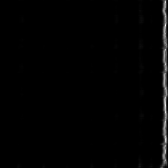
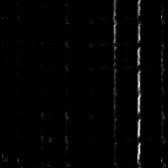
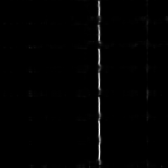
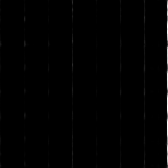

In [130]:
attn_weights_4h[0][0][0].shape
# attn_weights are 8,8,168,168
# B, nheads, S, S
media.show_images(attn_weights_4h[0][1])

,,,,,,,

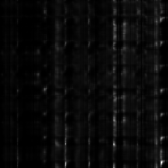
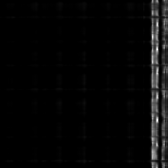
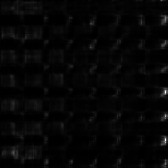
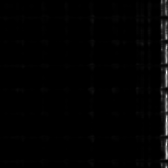
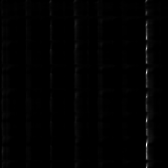
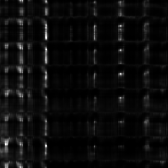
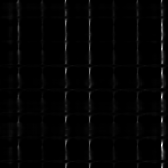
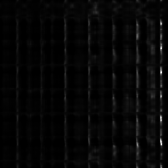

In [108]:
import mediapy as media
media.show_images(attn_weights[0][1])

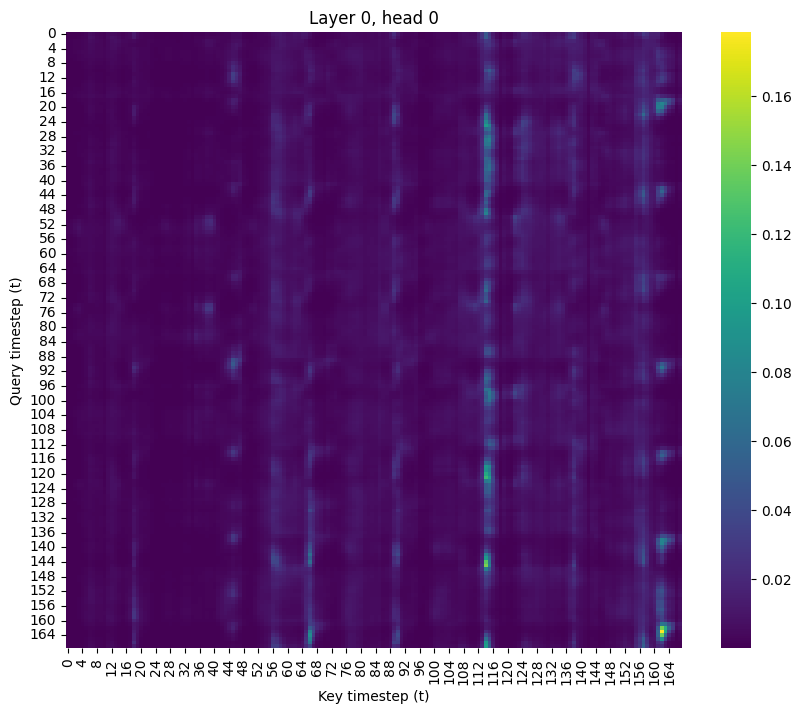

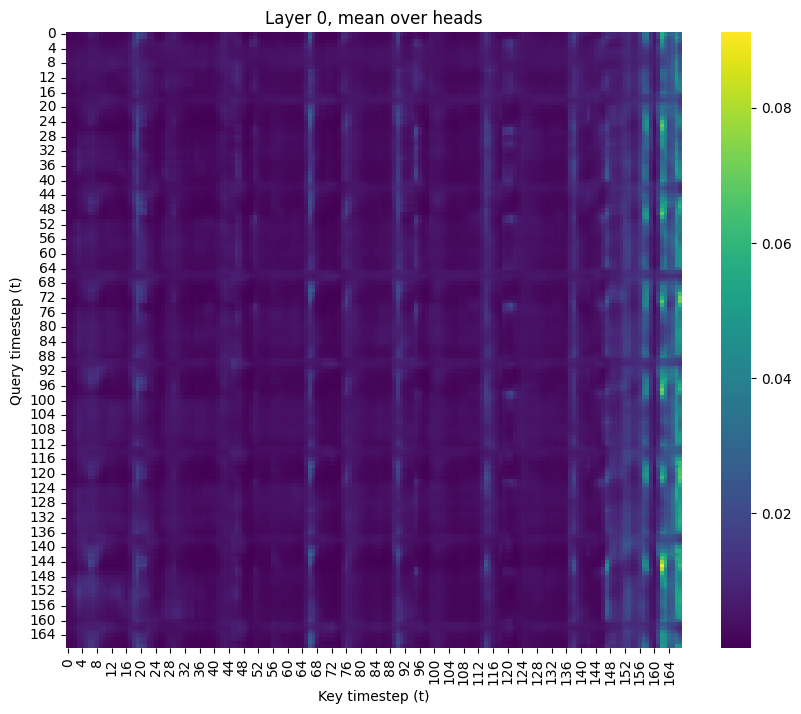

In [110]:
def plot_attn(w, layer_idx=0, head_idx=None, example_idx=0, title=None):
    # w: [B, H, L, L]
    w = w[example_idx]  # [H, L, L]
    if head_idx is not None:
        w = w[head_idx]  # [L, L]
    else:
        w = w.mean(dim=0)  # [L, L], averaged over heads

    plt.figure(figsize=(10, 8))
    sns.heatmap(w.numpy(), cmap="viridis", square=True, cbar=True)
    if title is None:
        title = f"Attention map (layer {layer_idx}, head {head_idx}, example {example_idx})"
    plt.title(title)
    plt.xlabel("Key timestep (t)")
    plt.ylabel("Query timestep (t)")
    plt.show()

# Example: first layer, first head, first example
plot_attn(attn_weights[0], layer_idx=0, head_idx=0, title="Layer 0, head 0")

# Example: mean over heads, first example
plot_attn(attn_weights[0], layer_idx=0, head_idx=None, title="Layer 0, mean over heads")

In [ ]:
# Say you know which sample index corresponds to a 1h, 3h, 6h case:
for h_name, t in [("1h", 0), ("3h", 8), ("6h", 16)]:
    for i, w in enumerate(all_attn_weights):
        plot_attn(
            w,
            layer_idx=i,
            head_idx=None,
            example_idx=t,
            title=f"Horizon {h_name}, Layer {i} (mean over heads)"
        )